In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split



In [5]:
data = pd.read_csv(r"D:\Brigader\new_cleaned_preprocessed.csv")

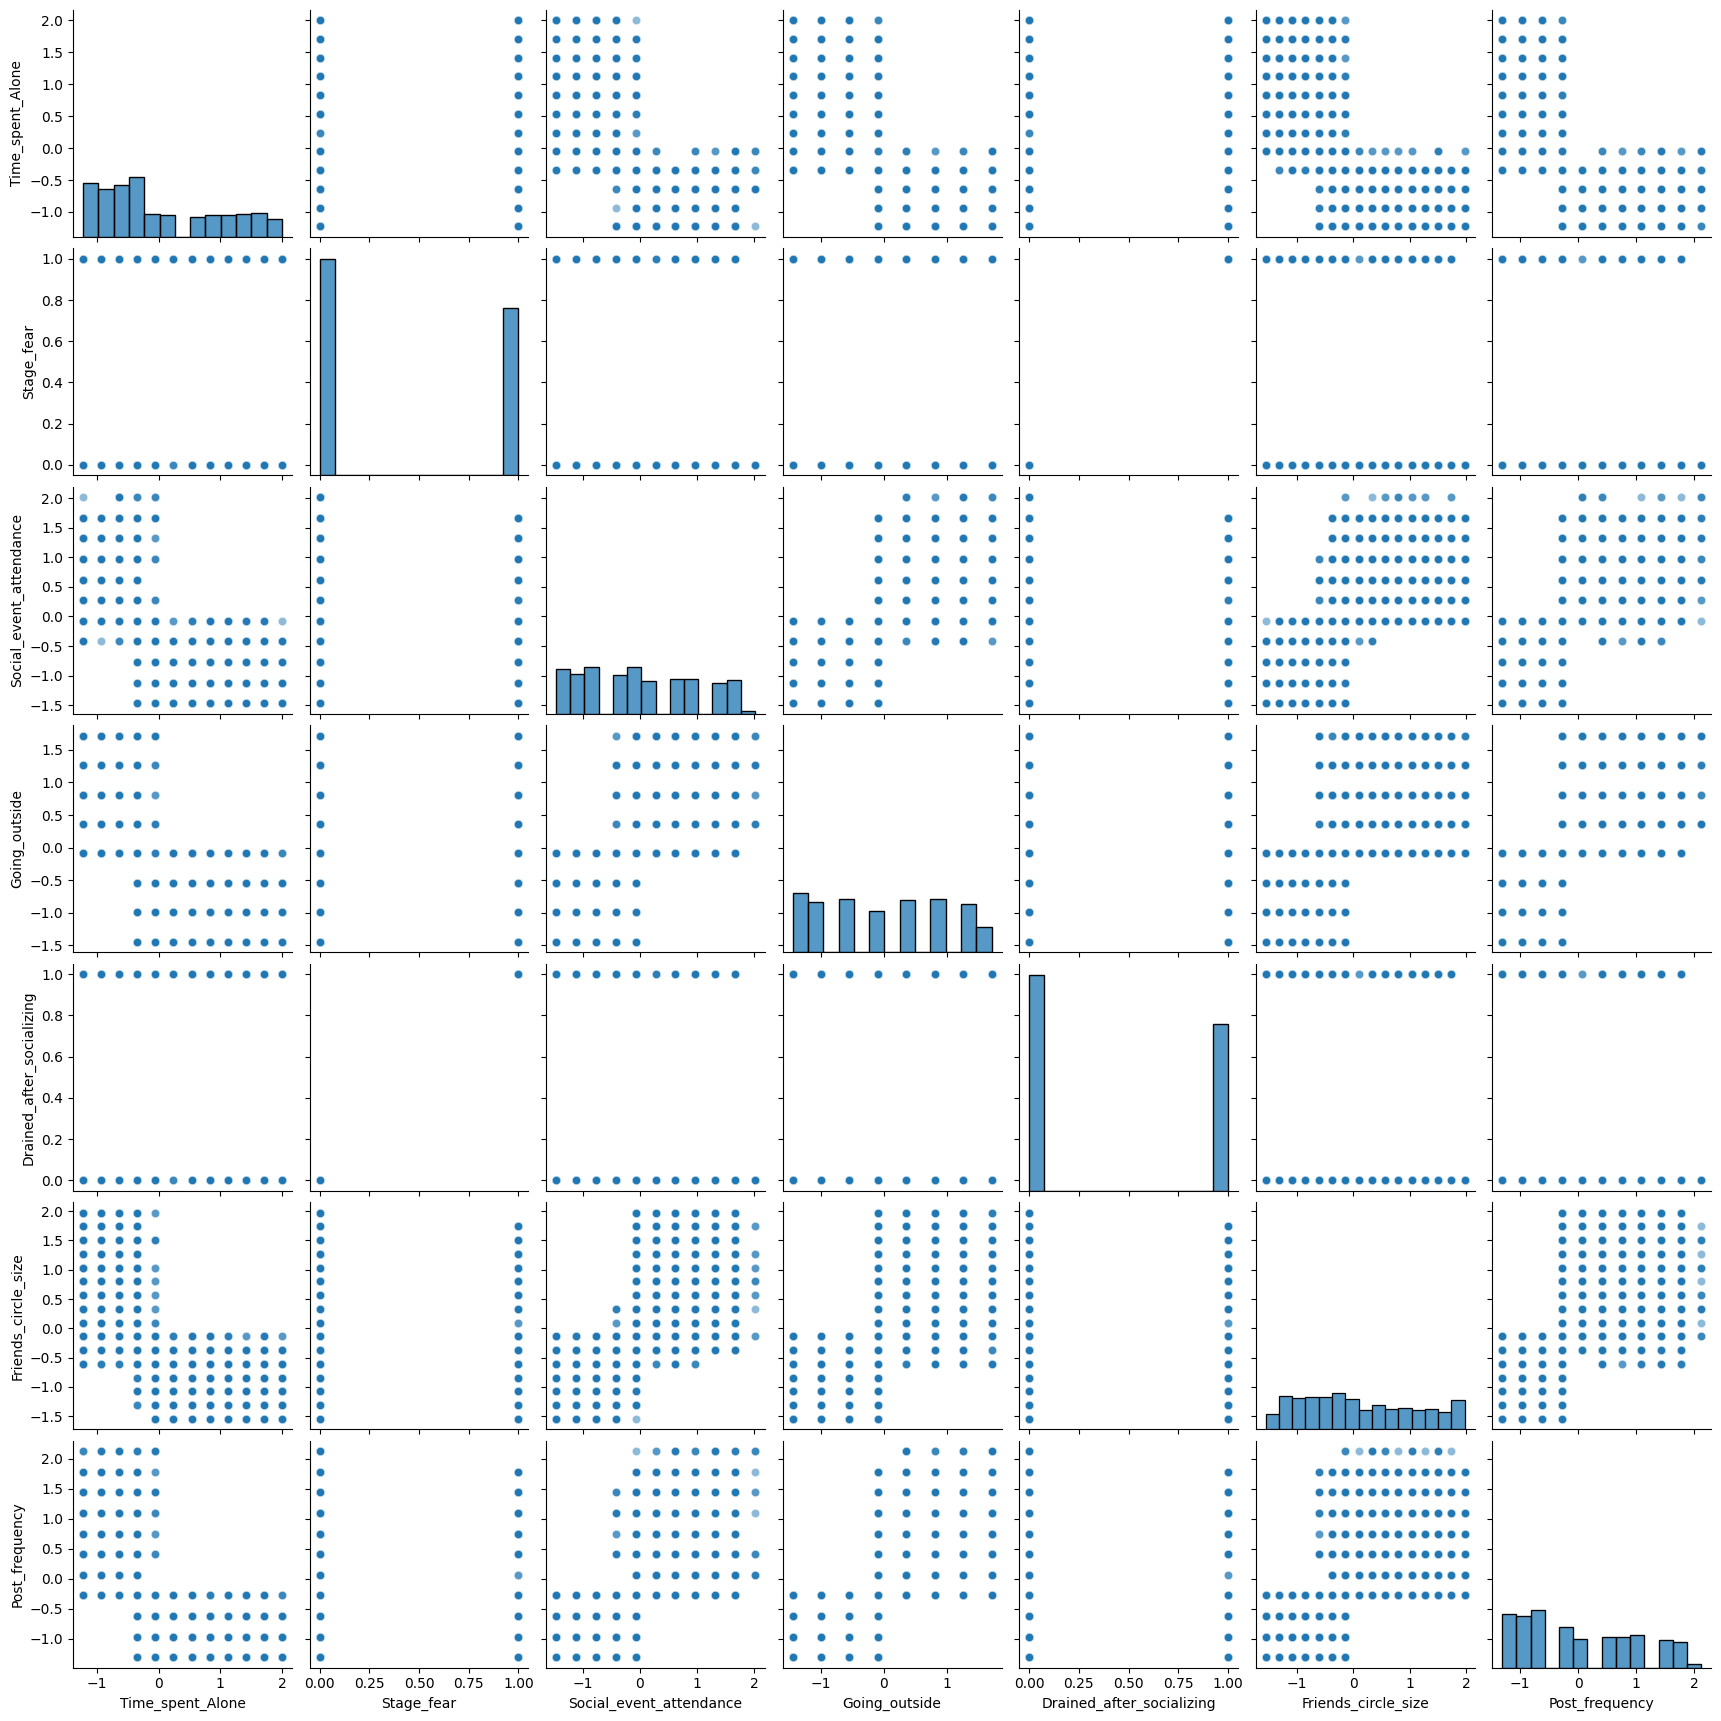

In [6]:
sns.pairplot(data =data, kind = 'scatter', plot_kws = {'alpha': 0.5})

In [7]:
encoder = LabelEncoder()
data['Personality'] = encoder.fit_transform(data['Personality'])

<Axes: xlabel='Personality', ylabel='count'>

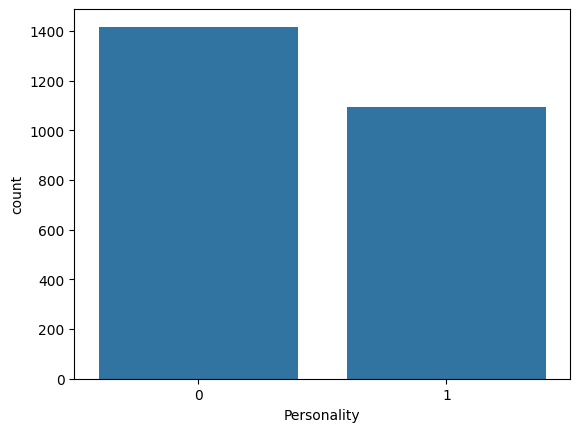

In [8]:
sns.countplot(data = data , x = 'Personality')

In [9]:
X = data.drop('Personality', axis = 1)
Y = data['Personality']


In [80]:
X

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
0,-0.052790,0,-0.074405,1.264030,0,1.504968,0.408089
1,1.414117,1,-1.466616,-1.443298,1,-1.546835,-0.278069
2,1.414117,1,-1.118563,-0.540855,1,-0.373064,-0.621148
3,-1.226315,0,0.621701,1.715252,0,1.739722,1.437327
4,-0.346171,0,1.665860,0.361588,0,0.331198,0.408089
...,...,...,...,...,...,...,...
2507,-1.226315,0,1.665860,-0.089634,0,1.270214,-0.278069
2508,-0.346171,0,1.317807,-0.089634,0,1.739722,1.780406
2509,-0.052790,1,-1.118563,-0.992076,1,-0.607818,-1.307306
2510,2.000879,1,-1.118563,-0.089634,1,-1.077326,-1.307306


In [79]:
X_train

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
476,-0.639553,0,1.665860,0.361588,0,1.035460,0.065010
36,-0.932934,0,-0.074405,0.361588,0,1.974476,0.065010
2203,-0.346171,0,0.621701,0.361588,0,-0.373064,-0.278069
2414,-1.226315,0,1.665860,-0.089634,0,-0.138310,1.780406
743,1.120735,1,-1.118563,-0.992076,1,-0.842572,-0.621148
...,...,...,...,...,...,...,...
2226,0.827354,1,-1.118563,-1.443298,1,-1.077326,-0.964227
1532,-0.346171,0,0.621701,0.812809,0,1.504968,1.780406
2303,-0.052790,1,-0.770510,-1.443298,1,-1.077326,-0.621148
2215,0.533973,1,-1.118563,-1.443298,1,-0.373064,-0.621148


In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 43)

model = LogisticRegression()
model.fit(X_train, Y_train)

predictions = model.predict(X_test)

In [61]:
X_test.tail()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
2248,-1.226315,0,-0.074405,-0.089634,0,1.035460,0.408089
2092,1.707498,1,-1.466616,-0.540855,1,-0.842572,-0.621148
124,-0.346171,1,-0.422457,-1.443298,1,-1.077326,-0.964227
1892,-0.052790,1,-1.466616,-0.992076,1,-0.373064,-1.307306
2165,-0.932934,0,0.273648,0.361588,0,1.035460,1.094248


In [62]:
pred_prob = model.predict_proba(X_test)

In [13]:
from sklearn.metrics import accuracy_score, recall_score,f1_score, confusion_matrix,roc_auc_score, roc_curve, precision_score



In [64]:
print("Accuracy:", accuracy_score(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))
print("Precision:", precision_score(Y_test, predictions))
print("Recall:", recall_score(Y_test, predictions))
print("F1 Score:", f1_score(Y_test,predictions))
print("ROC AUC:", roc_auc_score(Y_test,predictions))

Accuracy: 1.0
Confusion Matrix:
 [[284   0]
 [  0 219]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC AUC: 1.0


In [67]:
new_input = (0.12345,1,-0.12345,0.56789,1,0.67890,1.34567)
new_input_asarray = np.asarray(new_input)
new_data_reshaped = new_input_asarray.reshape(1,-1)


In [68]:
new_pred = model.predict(new_data_reshaped)

C:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [69]:
new_pred = "Introvert" if new_pred[0] == 1 else "Extrovert"

print(f"The person is {new_pred}")

The person is Introvert


In [74]:
cols = X_train.columns
new_data = pd.DataFrame([
    [1.70749787, 1, -1.118563162, -0.089633538, 1, -1.546834502, -0.278068893],
    [-1.22631516, 0, 1.317806793, 1.264030472, 0, 1.504967546, 1.437326634],
    [-0.346171251, 0, 1.665859643, 1.264030472, 0, 1.974475553, 0.408089318],
    [1.70749787, 1, -0.422457461, -0.992076211, 1, -0.607818487, -1.307306208],
    [-0.346171251, 0, 0.621701091, 1.715251808, 0, 1.739721549, 2.123484844],
    [-0.346171251, 0, 0.621701091, 0.361587799, 0, 0.800705535, 1.094247528],
    [0.533972658, 1, -0.422457461, -1.443297547, 1, -1.312080498, -0.278068893],
    [-1.22631516, 0, -0.07440461, 0.361587799, 0, 0.331197527, 1.437326634],
    [1.414116567, 1, -1.466616013, -1.443297547, 1, -1.546834502, -1.307306208]
], columns = cols)


In [88]:
pred_labels = model.predict(new_data)
pred_labels = ["Introvert" if label == 1 else "Extrovert" for label in pred_labels]

# Predicted probabilities for each class
pred_probs = model.predict_proba(new_data)


In [89]:
results = pd.DataFrame({
    'Predicted_Label': pred_labels,
    'Prob_Introvert': pred_probs[:, 1],
    'Prob_Extrovert': pred_probs[:, 0]
})
print(results)


  Predicted_Label  Prob_Introvert  Prob_Extrovert
0       Introvert        0.996392        0.003608
1       Extrovert        0.001347        0.998653
2       Extrovert        0.001932        0.998068
3       Introvert        0.997108        0.002892
4       Extrovert        0.001377        0.998623
5       Extrovert        0.003008        0.996992
6       Introvert        0.995832        0.004168
7       Extrovert        0.002797        0.997203
8       Introvert        0.998122        0.001878


In [11]:
from sklearn.ensemble import RandomForestClassifier

1.0
1.0


<Axes: >

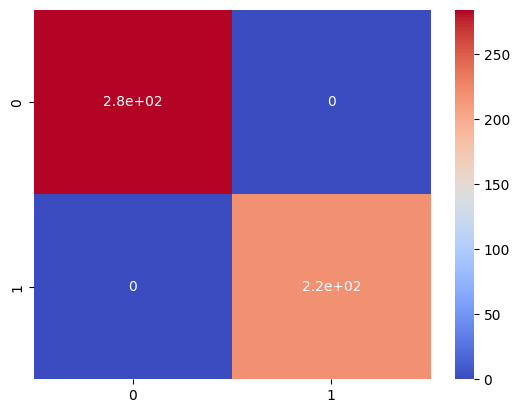

In [19]:
RFC = RandomForestClassifier(criterion = 'entropy', max_depth = 5, min_samples_split = 3, mmin_samples_leaf = )
RFC.fit(X_train, Y_train)

y_pred = RFC.predict(X_test)
y_pred_train = RFC.predict(X_train)

print(accuracy_score(Y_test, y_pred))
print(accuracy_score(Y_train, y_pred_train))
con_math = confusion_matrix(Y_test, y_pred)

sns.heatmap(con_math, cmap = 'coolwarm', annot = True)

In [15]:
cols = X_train.columns
new_data = pd.DataFrame([
    [1.70749787, 1, -1.118563162, -0.089633538, 1, -1.546834502, -0.278068893],
    [-1.22631516, 0, 1.317806793, 1.264030472, 0, 1.504967546, 1.437326634],
    [-0.346171251, 0, 1.665859643, 1.264030472, 0, 1.974475553, 0.408089318],
    [1.70749787, 1, -0.422457461, -0.992076211, 1, -0.607818487, -1.307306208],
    [-0.346171251, 0, 0.621701091, 1.715251808, 0, 1.739721549, 2.123484844],
    [-0.346171251, 0, 0.621701091, 0.361587799, 0, 0.800705535, 1.094247528],
    [0.533972658, 1, -0.422457461, -1.443297547, 1, -1.312080498, -0.278068893],
    [-1.22631516, 0, -0.07440461, 0.361587799, 0, 0.331197527, 1.437326634],
    [1.414116567, 1, -1.466616013, -1.443297547, 1, -1.546834502, -1.307306208]
], columns = cols)


In [16]:
pred_labels = RFC.predict(new_data)
pred_labels = ["Introvert" if label == 1 else "Extrovert" for label in pred_labels]

In [18]:
results = pd.DataFrame({
    'Predicted_Label': pred_labels,
})
print(results)

  Predicted_Label
0       Introvert
1       Extrovert
2       Extrovert
3       Introvert
4       Extrovert
5       Extrovert
6       Introvert
7       Extrovert
8       Introvert
